# CopThief — Results Analysis

Analyses match results and the audit trail, with parameter sweeps.
Run from the project root: `uv run jupyter lab`.

1. Setup
2. Latest match: outcomes and per-subgame scores
3. Parameter sweep: grid size vs. effort to capture
4. Audit-trail sanity check
5. Partial observation: cop-win rate vs vision radius

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from copthief.constants import Role
from copthief.llm.mock import MockProvider
from copthief.orchestrator.agent import Agent
from copthief.orchestrator.match import MatchRunner
from copthief.shared.logger import AuditLog
from copthief.strategy.factory import build_strategy

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
AUDIT = ROOT / "logs" / "game_audit.log"
SCORING = {"cop_win": 20, "thief_win": 10, "cop_loss": 5, "thief_loss": 5}
print("root:", ROOT)

root: C:\Users\Alon\Desktop\ex6


## 2. Latest match: outcomes and per-subgame scores

loaded: internal_20260621_224123.json | totals: {'cop': 60, 'thief': 50}


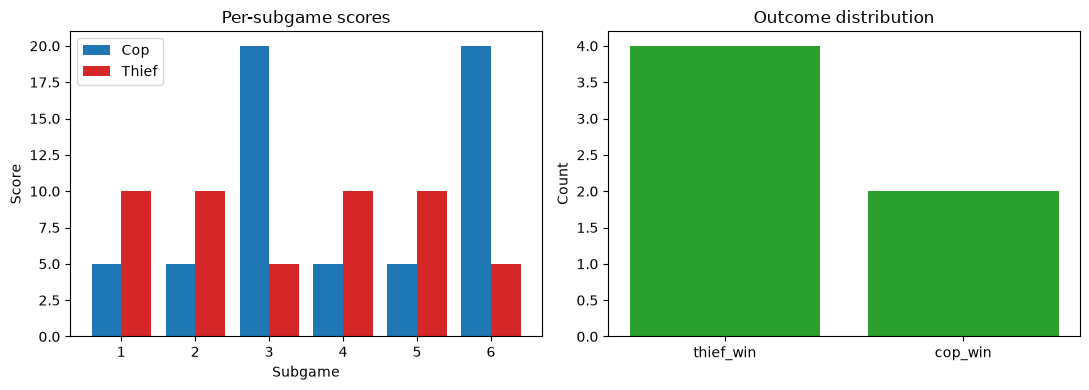

In [2]:
reports = sorted(RESULTS.glob("*.json"))
assert reports, "No reports found - run `uv run copthief selfplay` first."
report = json.loads(reports[-1].read_text(encoding="utf-8"))
sub = report["sub_games"]
print("loaded:", reports[-1].name, "| totals:", report["totals"])

idx = [s["index"] for s in sub]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
width = 0.4
ax1.bar([i - width / 2 for i in idx], [s["cop_score"] for s in sub], width,
        label="Cop", color="tab:blue")
ax1.bar([i + width / 2 for i in idx], [s["thief_score"] for s in sub], width,
        label="Thief", color="tab:red")
ax1.set_xlabel("Subgame"); ax1.set_ylabel("Score"); ax1.set_title("Per-subgame scores")
ax1.legend()
counts = Counter(s["outcome"] for s in sub)
ax2.bar(list(counts.keys()), list(counts.values()), color="tab:green")
ax2.set_title("Outcome distribution"); ax2.set_ylabel("Count")
plt.tight_layout(); plt.show()

## 3. Parameter sweep: grid size vs. effort to capture

Full-observability self-play; measures cop capture rate and average moves to capture.

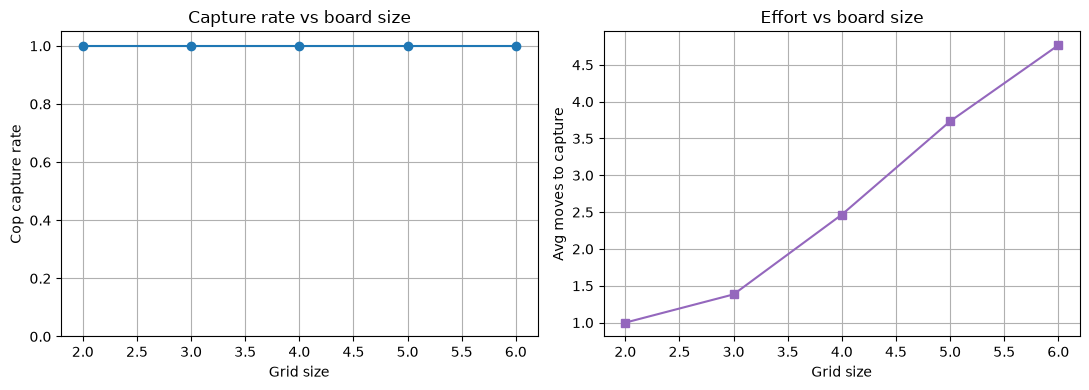

[(2, 1.0, 1.0), (3, 1.0, 1.38), (4, 1.0, 2.47), (5, 1.0, 3.73), (6, 1.0, 4.77)]

In [3]:
def sweep(size, trials=60, seed=0):
    audit = AuditLog(ROOT, {"log_dir": "logs", "game_log_file": "sweep.log"})
    cfg = {"grid_size": [size, size], "max_moves": 25, "num_games": trials,
           "max_barriers": 5, "origin": 1, "diagonal_moves": True, "disclosure": "exact"}
    cop = Agent(Role.COP, build_strategy({"kind": "adaptive"}), MockProvider())
    thief = Agent(Role.THIEF, build_strategy({"kind": "adaptive"}), MockProvider())
    res = MatchRunner(cfg, SCORING, cop, thief, audit, random.Random(seed)).run_match()
    wins = [s for s in res["sub_games"] if s["outcome"] == "cop_win"]
    rate = len(wins) / trials
    avg = sum(s["moves_played"] for s in wins) / len(wins) if wins else 0.0
    return rate, avg

sizes = [2, 3, 4, 5, 6]
rates, moves = zip(*[sweep(s) for s in sizes], strict=True)
fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(sizes, rates, marker="o", color="tab:blue"); axa.set_ylim(0, 1.05)
axa.set_xlabel("Grid size"); axa.set_ylabel("Cop capture rate"); axa.grid(True)
axa.set_title("Capture rate vs board size")
axb.plot(sizes, moves, marker="s", color="tab:purple")
axb.set_xlabel("Grid size"); axb.set_ylabel("Avg moves to capture"); axb.grid(True)
axb.set_title("Effort vs board size")
plt.tight_layout(); plt.show()
list(zip(sizes, [round(r, 2) for r in rates], [round(m, 2) for m in moves], strict=True))

## 4. Audit-trail sanity check

Confirms every turn is logged and no illegal move was ever committed by the referee.

In [4]:
lines = []
if AUDIT.exists():
    lines = [json.loads(x) for x in AUDIT.read_text(encoding="utf-8").splitlines()]
events = Counter(e["event"] for e in lines)
turns = [e for e in lines if e["event"] == "turn"]
illegal = [t for t in turns if not t.get("legal", True)]
hidden = [t for t in turns if t.get("revealed") is False]
print("event counts:", dict(events))
print("turns:", len(turns), "| illegal committed:", len(illegal), "| hidden turns:", len(hidden))

event counts: {'negotiation': 2, 'subgame_start': 6, 'turn': 206, 'subgame_end': 6, 'match_complete': 1}
turns: 206 | illegal committed: 0 | hidden turns: 200


## 5. Partial observation: cop-win rate vs vision radius

Under **full observability** the cop always wins on 5×5. Under **partial** disclosure
with a small **vision radius**, the thief hides when unseen and escapes far more often —
quantifying the DecPOMDP challenge (PDF §4.5).

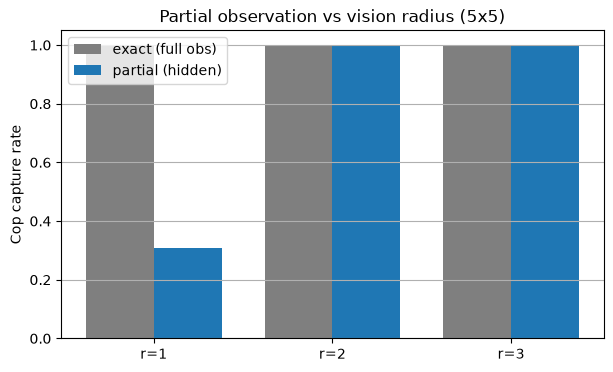

[(1, 1.0, 0.31), (2, 1.0, 1.0), (3, 1.0, 1.0)]

In [5]:
def cop_win_rate(radius, disclosure, trials=120):
    cfg = {"grid_size": [5, 5], "max_moves": 25, "num_games": trials, "max_barriers": 5,
           "origin": 1, "diagonal_moves": True, "vision_radius": radius,
           "disclosure": disclosure, "deception": False}
    audit = AuditLog(ROOT, {"log_dir": "logs", "game_log_file": "vis.log"})
    strat = {"kind": "adaptive", "cop_uses_barriers": True}
    cop = Agent(Role.COP, build_strategy(strat), MockProvider())
    thief = Agent(Role.THIEF, build_strategy(strat), MockProvider())
    res = MatchRunner(cfg, SCORING, cop, thief, audit, random.Random(1)).run_match()
    return sum(1 for s in res["sub_games"] if s["outcome"] == "cop_win") / trials

radii = [1, 2, 3]
exact = [cop_win_rate(r, "exact") for r in radii]
partial = [cop_win_rate(r, "partial") for r in radii]
x = np.arange(len(radii)); w = 0.38
plt.figure(figsize=(7, 4))
plt.bar(x - w / 2, exact, w, label="exact (full obs)", color="tab:gray")
plt.bar(x + w / 2, partial, w, label="partial (hidden)", color="tab:blue")
plt.xticks(x, [f"r={r}" for r in radii]); plt.ylim(0, 1.05)
plt.ylabel("Cop capture rate"); plt.title("Partial observation vs vision radius (5x5)")
plt.legend(); plt.grid(True, axis="y"); plt.show()
list(zip(radii, [round(e, 2) for e in exact], [round(p, 2) for p in partial], strict=True))